<a href="https://colab.research.google.com/github/danielcorrea96/AprendizajePorRefuerzo/blob/main/Proyecto_pra%CC%81ctico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Actividad - Proyecto práctico


> La actividad se desarrollará en grupos pre-definidos de 4 alumnos. Se debe indicar los nombres en orden alfabético (de apellidos). Recordad que esta actividad se corresponde con un 30% de la nota final de la asignatura. Se debe entregar entregar el trabajo en la presente notebook.
*   Alumno 1: Daniel Alfonso Correa Angarita
*   Alumno 2: Cesar Daniel Meneses Guevara
*   Alumno 3: America Garrido Sánchez

**Colab**:

**Evidencias de entrenamiento**: En esta [carpeta compartida de google drive]() se guardas los pesos .......

**Videos Agente Jugando**:


---
## **PARTE 1** - Instalación y requisitos previos

> Las prácticas han sido preparadas para poder realizarse en el entorno de trabajo de Google Colab. Sin embargo, esta plataforma presenta ciertas incompatibilidades a la hora de visualizar la renderización en gym. Por ello, para obtener estas visualizaciones, se deberá trasladar el entorno de trabajo a local. Por ello, el presente dosier presenta instrucciones para poder trabajar en ambos entornos. Siga los siguientes pasos para un correcto funcionamiento:
1.   **LOCAL:** Preparar el enviroment, siguiendo las intrucciones detalladas en la sección *1.1.Preparar enviroment*.
2.  **AMBOS:** Modificar las variables "mount" y "drive_mount" a la carpeta de trabajo en drive en el caso de estar en Colab, y ejecturar la celda *1.2.Localizar entorno de trabajo*.
3. **COLAB:** se deberá ejecutar las celdas correspondientes al montaje de la carpeta de trabajo en Drive. Esta corresponde a la sección *1.3.Montar carpeta de datos local*.
4.  **AMBOS:** Instalar las librerías necesarias, siguiendo la sección *1.4.Instalar librerías necesarias*.


---
### 1.1. Preparar enviroment (solo local)



> Para preparar el entorno de trabajo en local, se han seguido los siguientes pasos:
1. En Windows, puede ser necesario instalar las C++ Build Tools. Para ello, siga los siguientes pasos. Alternativamente puedes utilizar WSL2: https://towardsdatascience.com/how-to-install-openai-gym-in-a-windows-environment-338969e24d30.
2. Instalar Anaconda
3. Siguiendo el código que se presenta comentado en la próxima celda: Crear un enviroment, cambiar la ruta de trabajo, e instalar librerías básicas.


```
conda create --name miar_rl python=3.8
conda activate miar_rl
cd "PATH_TO_FOLDER"
conda install git
pip install jupyter
```


4. Abrir la notebook con *jupyter-notebook*.



```
jupyter-notebook
```


---
### 1.2. Localizar entorno de trabajo: Google colab o local

In [ ]:
# ATENCIÓN!! Modificar ruta relativa a la práctica si es distinta (drive_root)
mount='/content/gdrive'
drive_root = mount + "/My Drive/08_MIAR/actividades/proyecto practico"

try:
  from google.colab import drive
  IN_COLAB=True
except:
  IN_COLAB=False

---
### 1.3. Montar carpeta de datos local (solo Colab)

In [ ]:
import os
if IN_COLAB:
  print("We're running Colab")

  if IN_COLAB:
    print("Colab: mounting Google drive on ", mount)

    drive.mount(mount)

    create_drive_root = True
    if create_drive_root:
      print("\nColab: making sure ", drive_root, " exists.")
      os.makedirs(drive_root, exist_ok=True)

    print("\nColab: Changing directory to ", drive_root)
    %cd $drive_root
%pwd
print("Archivos en el directorio: ")
print(os.listdir())

We're running Colab
Colab: mounting Google drive on  /content/gdrive
Mounted at /content/gdrive

Colab: making sure  /content/gdrive/My Drive/08_MIAR/actividades/proyecto practico  exists.

Colab: Changing directory to  /content/gdrive/My Drive/08_MIAR/actividades/proyecto practico
/content/gdrive/My Drive/08_MIAR/actividades/proyecto practico
Archivos en el directorio: 
['dqn dueling', 'dqn spartial', 'dqn clasico']


---
### 1.4. Instalar librerías necesarias

In [ ]:
if IN_COLAB:
  !pip uninstall jax jaxlib ml-dtypes -y
  %pip install --upgrade ml_dtypes==0.5.0

  %pip install tensorflow==2.18.0
  %pip install tf-keras==2.18.0
  %pip install gym==0.17.3
  %pip install git+https://github.com/Kojoley/atari-py.git
  %pip install keras-rl2==1.0.5

  print(f"Ecosistema clásico cargado en la nube de Google.")

else:
  """
  %pip install gym==0.17.3
  %pip install git+https://github.com/Kojoley/atari-py.git
  %pip install pyglet==1.5.0
  %pip install h5py==3.1.0
  %pip install Pillow==9.5.0
  %pip install keras-rl2==1.0.5
  %pip install Keras==2.2.4
  %pip install tensorflow==2.5.3
  %pip install torch==2.0.1
  %pip install agents==1.4.0
 """
  %pip install numpy pandas matplotlib seaborn tensorflow==2.18.0

Found existing installation: jax 0.7.2
Uninstalling jax-0.7.2:
  Successfully uninstalled jax-0.7.2
Found existing installation: jaxlib 0.7.2
Uninstalling jaxlib-0.7.2:
  Successfully uninstalled jaxlib-0.7.2
Found existing installation: ml_dtypes 0.5.4
Uninstalling ml_dtypes-0.5.4:
  Successfully uninstalled ml_dtypes-0.5.4
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 20.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
orbax-checkpoint 0.12.0 requires jax>=0.6.0, which is not installed.
flax 0.11.2 requires jax>=0.6.0, which is not installed.
tensorflow 2.20.0 requires ml_dtypes<1.0.0,>=0.5.1, but you have ml-dtypes 0.5.0 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 615.5/615.5 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

---
## **PARTE 2**. Enunciado

Consideraciones a tener en cuenta:

- El entorno sobre el que trabajaremos será el indicado en el listado correspondien de cada grupo y el algoritmo que usaremos será _DQN_.

- Para nuestro ejercicio, el requisito mínimo será alcanzado cuando el agente consiga una **media de recompensa por encima de los puntos indicados en el listado por grupos en modo test**. Por ello, esta media de la recompensa se calculará a partir del código de test en la última celda del notebook.

Este proyecto práctico consta de tres partes:

1.   Implementar la red neuronal que se usará en la solución
2.   Implementar las distintas piezas de la solución DQN y probar al menos 3 propuestas diferentes de mejora.
3.   Justificar la respuesta en relación a los resultados obtenidos e incluir al menos 3 gráficas relevantes comparando las 3 propuestas.

**Rúbrica**: Se valorará la originalidad en la solución aportada, así como la capacidad de discutir los resultados de forma detallada. El requisito mínimo servirá para aprobar la actividad, bajo premisa de que la discusión del resultado sera apropiada.

IMPORTANTE:

* Si no se consigue una puntuación óptima, responder sobre la mejor puntuación obtenida.
* Para entrenamientos largos, recordad que podéis usar checkpoints de vuestros modelos para retomar los entrenamientos. En este caso, recordad cambiar los parámetros adecuadamente (sobre todo los relacionados con el proceso de exploración).
* Se deberá entregar unicamente el notebook y los pesos del mejor modelo en un fichero .zip, de forma organizada.
* Cada alumno deberá de subir la solución de forma individual.

### **SpaceInvaders-v0**

En nuestro caso es necesario realizar el entrenamiento por refuerzo en el ambiente en el entorno de **SpaceInvaders-v0** la documentación se encuentra en https://ale.farama.org/environments/space_invaders/.

Le objetivo en nuestro caso es:
- Alcanzar más de 20 puntos con reward clipping durante más de 100 episodios consecutivos

---
## **PARTE 3**. Desarrollo y preguntas

#### Importar librerías

In [ ]:
import os
os.environ['TF_USE_LEGACY_KERAS']="1"

import tensorflow.keras as tf
import tensorflow as tf1

from keras import __version__
tf.__version__ = __version__

print(tf1.__version__)
print(tf1.config.list_physical_devices('GPU'))
print(tf1.config.list_logical_devices('GPU'))

2.18.0
[]
[]


In [ ]:

from __future__ import division

# -------------

import sys
import os

# PARCHE DE COMPATIBILIDAD K2 PARA TENSORFLOW 2.18 + KERAS-RL2
import tensorflow.keras.models as keras_models
import tf_keras
from tf_keras.models import model_from_config
keras_models.model_from_config = model_from_config
sys.modules['tensorflow.keras.models'].model_from_config = model_from_config

if 'keras.models' in sys.modules:
    sys.modules['keras.models'].model_from_config = model_from_config

print("Parche 'model_from_config' inyectado con éxito usando tf-keras.")

# -------------

from PIL import Image
import numpy as np
import gym
import csv
import os

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Activation, Flatten, Conv2D, Permute, SpatialDropout2D, Input, Lambda

from tensorflow.keras.optimizers.legacy import Adam
import tensorflow.keras.backend as K

from rl.agents.dqn import DQNAgent
from rl.policy import LinearAnnealedPolicy, BoltzmannQPolicy, EpsGreedyQPolicy
from rl.memory import SequentialMemory
from rl.core import Processor
from rl.callbacks import FileLogger, ModelIntervalCheckpoint, Callback

print("Todos los módulos y agentes de Keras-RL2 cargados correctamente")

Parche 'model_from_config' inyectado con éxito usando tf-keras.
Todos los módulos y agentes de Keras-RL2 cargados correctamente


In [ ]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def graph_training(logs_path, model_name, variables=['mean_q']):
    """
    Lee los logs en JSON y genera una cuadrícula 1x3 con las variables solicitadas.
    """
    with open(logs_path, 'r') as f:
        data = json.load(f)

    # Crear una figura con 1 fila y 3 columnas, ajustando el tamaño
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"Rendimiento de Entrenamiento: {model_name}", fontsize=16, y=1.05)

    for i, var in enumerate(variables):
        if var in data:
            # Extraemos los datos para la variable actual
            df_var = pd.DataFrame(data[var]).dropna()

            # Graficamos en el sub-gráfico correspondiente (axes[i])
            df_var.plot(ax=axes[i], legend=False, color='#1f77b4') # Azul clásico

            # Configuramos títulos y etiquetas
            axes[i].set_title(f"Evolución de {var}")
            axes[i].set_xlabel('Steps')
            axes[i].set_ylabel(var)
            axes[i].grid(True, linestyle='--', alpha=0.7) # Cuadrícula para mejor lectura
        else:
            print(f"Advertencia: La variable '{var}' no se encontró en {logs_path}")

    # Ajusta el espaciado para que no se superpongan los textos
    plt.tight_layout()

    # Manejo de rutas y guardado
    # os.path.dirname(logs_path) obtiene la carpeta donde está el JSON
    path_imgs = os.path.join(os.path.dirname(logs_path), "imgs")
    os.makedirs(path_imgs, exist_ok=True)

    save_path = os.path.join(path_imgs, f"{model_name}_metricas_cuadricula.png")
    plt.savefig(save_path, bbox_inches='tight')
    plt.show() # Muestra la gráfica en el notebook antes de continuar


def graph_test_results(test_metrics, model_name):
    """
    Recibe el diccionario de resultados del test y genera una cuadrícula 1x3.
    """
    rewards = test_metrics['episode_reward']
    steps = test_metrics['nb_steps']
    episodios = range(1, len(rewards) + 1)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"Resultados de Evaluación (Test): {model_name}", fontsize=16, y=1.05)

    # 1. Gráfica de Recompensas a lo largo de los episodios
    axes[0].plot(episodios, rewards, marker='o', linestyle='-', color='#2ca02c')
    axes[0].set_title("Rewards por Episodio")
    axes[0].set_xlabel("Número de Episodio")
    axes[0].set_ylabel("Reward")
    axes[0].grid(True, linestyle='--', alpha=0.7)

    # 2. Gráfica de Supervivencia (Pasos por episodio)
    axes[1].plot(episodios, steps, marker='s', linestyle='-', color='#ff7f0e')
    axes[1].set_title("Supervivencia (Pasos por Episodio)")
    axes[1].set_xlabel("Número de Episodio")
    axes[1].set_ylabel("Cantidad de Steps")
    axes[1].grid(True, linestyle='--', alpha=0.7)

    # 3. Diagrama de Caja (Boxplot) para ver la estabilidad
    caja = axes[2].boxplot(rewards, vert=True, patch_artist=True)
    caja['boxes'][0].set_facecolor('#1f77b4') # Color azul de relleno
    axes[2].set_title("Distribución de Rewards")
    axes[2].set_ylabel("Reward")
    axes[2].set_xticks([1])
    axes[2].set_xticklabels([f'{len(rewards)} Episodios'])
    axes[2].grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

#### Configuración base

In [ ]:
BASE_CONFIG = {
    # Entorno y preprocesamiento
    'ENV_NAME': 'SpaceInvaders-v0',
    'WINDOW_LENGTH': 4,
    'INPUT_SHAPE': (84, 84),
    'SEED': 123,

    # Hiperparámetros del agente
    'learning_rate': 0.00025,
    'discount_factor': 0.99,
    'batch_size': 32,
    'target_update_freq': 5000,
    'train_frequency': 4,
    'learning_starts': 10000,

    # Exploración
    'epsilon_start': 1.0,
    'epsilon_end': 0.1,
    'epsilon_decay_steps': 750000,
    'epsilon_test': 0.05,

    # Memoria
    'memory_size': 800000,

    # Entrenamiento
    'max_steps': 1000000,
    'optimizer': 'adam',
    'gradient_clip': 1.0,
}

In [ ]:
from gym import Wrapper
import numpy as np

class FixedFrameSkip(Wrapper):
    def __init__(self, env, skip=BASE_CONFIG['WINDOW_LENGTH']):
        super(FixedFrameSkip, self).__init__(env)
        self._skip = skip
        if hasattr(self.env.unwrapped, 'ale'):
            self.env.unwrapped.frameskip = 1

    def step(self, action):
        total_reward = 0.0
        done = False
        info = {}

        for i in range(self._skip):
            obs, reward, done, info = self.env.step(action)
            total_reward += reward
            if done:
                break

        return obs, total_reward, done, info

In [ ]:
env_base = gym.make(BASE_CONFIG['ENV_NAME'])
env = FixedFrameSkip(env_base, skip=4)

np.random.seed(BASE_CONFIG["SEED"])
env.seed(BASE_CONFIG["SEED"])
nb_actions = env.action_space.n
print(f"Acciones disponibles: {str(nb_actions)}" )
print(f"Formato de las observaciones: {env.observation_space}")

Acciones disponibles: 6
Formato de las observaciones: Box(0, 255, (210, 160, 3), uint8)


In [ ]:
class AtariProcessor(Processor):
    def process_observation(self, observation):
        assert observation.ndim == 3
        img = Image.fromarray(observation)
        img = img.resize(BASE_CONFIG["INPUT_SHAPE"], Image.LANCZOS).convert('L')
        processed_observation = np.array(img)
        assert processed_observation.shape == BASE_CONFIG["INPUT_SHAPE"]
        return processed_observation.astype('uint8')

    def process_state_batch(self, batch):
        processed_batch = batch.astype('float32') / 255.
        return processed_batch

    def process_reward(self, reward):
        return np.clip(reward, -1., 1.)

In [ ]:
def create_memory():
  return SequentialMemory(
      limit=BASE_CONFIG['memory_size'],
      window_length=BASE_CONFIG['WINDOW_LENGTH']
  )

In [ ]:
def create_policy():
  return LinearAnnealedPolicy(
      EpsGreedyQPolicy(),
      attr='eps',
      value_max=BASE_CONFIG['epsilon_start'],
      value_min=BASE_CONFIG['epsilon_end'],
      value_test=BASE_CONFIG['epsilon_test'],
      nb_steps=BASE_CONFIG['epsilon_decay_steps']
  )

In [ ]:
def create_agent(model, nb_actions, enable_double=False):
  return DQNAgent(
      model=model,
      nb_actions=nb_actions,
      memory=create_memory(),
      nb_steps_warmup=BASE_CONFIG['learning_starts'],
      target_model_update=BASE_CONFIG['target_update_freq'],
      policy=create_policy(),
      processor=AtariProcessor(),
      batch_size=BASE_CONFIG['batch_size'],
      gamma=BASE_CONFIG['discount_factor'],
      train_interval=BASE_CONFIG['train_frequency'],
      enable_double_dqn=enable_double,
  )

In [ ]:
def compile_agent(agent):
  agent.compile(
      optimizer=Adam(
          learning_rate=BASE_CONFIG['learning_rate'],
          clipnorm=BASE_CONFIG['gradient_clip']
          ),
      metrics=['mae']
      )
  return agent

In [ ]:
import csv
from rl.callbacks import Callback
import os

class MetricLogger(Callback):
    def __init__(self, version, base_path):
        self.version = version
        self.folder = os.path.join(base_path, f"version_{version}")
        os.makedirs(self.folder, exist_ok=True)
        self.file_path = os.path.join(self.folder, "metricas.csv")
        self.fields = ['episode', 'steps', 'reward']

        archivo_existe = os.path.exists(self.file_path) and os.path.getsize(self.file_path) > 0
        modo = 'a' if archivo_existe else 'w'

        with open(self.file_path, modo, newline='') as f:
          if not archivo_existe:
            writer = csv.DictWriter(f, fieldnames=self.fields)
            writer.writeheader()

    def on_episode_end(self, episode, logs):
        row = {
            'episode': episode,
            'steps': logs.get('nb_steps'),
            'reward': logs.get('episode_reward')

        }

        with open(self.file_path, 'a', newline='') as f:
            writer = csv.DictWriter(f, fieldnames=self.fields)
            writer.writerow(row)

In [ ]:
class SaveWeightsInterval(Callback):
    def __init__(self, agent, version, interval, base_path="."):
        self.agent = agent
        self.version = version
        self.interval = interval
        self.folder = os.path.join(base_path, f"version_{version}", "pesos")
        os.makedirs(self.folder, exist_ok=True)

    def on_episode_end(self, episode, logs={}):
        if (episode % self.interval == 0):
            filename = os.path.join(self.folder, f"dqn_v_{self.version}_weights_{episode}_episodes.h5f")
            self.agent.save_weights(filename, overwrite=True)
            print(f"\n[Callback] Pesos guardados en: {filename}")

In [ ]:
from rl.callbacks import Callback
import os

class SaveBestWeights(Callback):
    def __init__(self, agent, version, base_path):
        self.agent = agent
        self.version = version
        self.best_reward = -float('inf')
        self.folder = os.path.join(base_path, f"version_{version}", "mejor_modelo")
        os.makedirs(self.folder, exist_ok=True)

    def on_episode_end(self, episode, logs={}):
        current_reward = logs.get('episode_reward')

        if current_reward is not None and current_reward > self.best_reward:
            self.best_reward = current_reward
            filename = os.path.join(self.folder, "best_weights.h5f")
            self.agent.save_weights(filename, overwrite=True)
            print(f"\nNuevo récord: {current_reward}. Pesos guardados en {filename}")

In [ ]:
class TotalStepStopper(Callback):
    def __init__(self, max_steps):
        super(TotalStepStopper, self).__init__()
        self.max_steps = max_steps

    def on_step_end(self, step, logs={}):
        if self.model.step >= self.max_steps:
            print(f"\n[Stopper] ¡Meta global alcanzada ({self.model.step} >= {self.max_steps})! Deteniendo...")
            self.model.stop_training = True

In [ ]:
import os
import glob
import re
import pandas as pd

def entrenando_modelo_con_recuperacion(agent, env, version, max_steps, carpeta_guardado, callbacks_lista, ruta_csv):
    """
    Busca los pesos más recientes, lee el CSV para saber el progreso exacto y continúa el entrenamiento.
    """
    os.makedirs(carpeta_guardado, exist_ok=True)

    # 1. Buscar los últimos pesos
    patron_busqueda = os.path.join(carpeta_guardado,f"version_{version}", "pesos",  f"dqn_v_{version}_weights_*_episodes.h5f.index")
    archivos = glob.glob(patron_busqueda)

    archivo_reciente_base = None
    max_episodio = -1

    for archivo in archivos:

        match = re.search(r'weights_(\d+)_episodes', archivo)

        if match:
            episodio = int(match.group(1))
            if episodio > max_episodio:
                max_episodio = episodio
                archivo_reciente_base = archivo[:-6]

    steps_reales_completados = 0

    if archivo_reciente_base:
        print(f"¡Guardado encontrado! Restaurando pesos desde el episodio {max_episodio}: {archivo_reciente_base}")
        agent.load_weights(archivo_reciente_base)

        try:
            if os.path.exists(ruta_csv):
                df = pd.read_csv(ruta_csv)
                steps_reales_completados = int(df['steps'].max())
                print(f"CSV leído correctamente. El modelo ya ha entrenado {steps_reales_completados} steps.")
            else:
                print("No se encontró el CSV. Asumiendo 0 steps (Peligro de sobreentrenamiento).")
        except Exception as e:
            print(f"Error al leer el CSV: {e}. Asumiendo 0 steps.")

    else:
        print("No se encontraron pesos previos. Iniciando desde cero.")


    steps_restantes = max_steps - steps_reales_completados

    if steps_restantes <= 0:
        print(f"El agente ya cumplió o superó la meta de los {max_steps} steps.")
        return None

    print(f"Retomando entrenamiento. Faltan exactamente: {steps_restantes} steps.")

    historial = agent.fit(
        env,
        nb_steps=steps_restantes,
        visualize=False,
        verbose=2,
        callbacks=callbacks_lista
    )

    return historial

In [ ]:
import os
import shutil
import glob
import numpy as np
from gym import wrappers

def evaluar_agente(agent, env, folder_path, video_dir=None, nb_episodes=5):
    weights_filename = os.path.join(folder_path, 'best_weights.h5f')
    agent.load_weights(weights_filename)
    agent.test_policy.eps = 0.0

    grabar_video = video_dir is not None
    local_video_folder = "/content/video_eval_temporal" if grabar_video else None

    if grabar_video:
        env_ejecucion = wrappers.Monitor(
            env,
            local_video_folder,
            force=True,
            video_callable=lambda episode_id: True
        )
    else:
        env_ejecucion = env

    print(f"-> Iniciando evaluación ({'Modo Video Activo' if grabar_video else 'Modo Métricas Puro'})...")
    results = agent.test(env_ejecucion, nb_episodes=nb_episodes, visualize=False, verbose=0)

    if grabar_video:
        env_ejecucion.close()
        os.makedirs(video_dir, exist_ok=True)
        for archivo in glob.glob(os.path.join(local_video_folder, "*")):
            shutil.copy(archivo, video_dir)
        print(f"Video exportado exitosamente a: {video_dir}")

    return results

def print_results(agent_name, results):
    rewards = results.history['episode_reward']

    print(f"Resultados del Agente: {agent_name}")
    print(f"Rendimiento promedio: {np.mean(rewards)}")
    print(f"Rendimiento mínimo: {np.min(rewards)}")
    print(f"Rendimiento máximo: {np.max(rewards)}")
    print(f"Desviación estándar: {np.std(rewards)}")

#### 1. Implementación de la red neuronal

In [ ]:
def create_dqn_model(input_shape, window_length, nb_actions, with_spatial_dropout = False):
  input_layer = Input(shape=(window_length,) + input_shape)

  print(K.image_data_format())
  if K.image_data_format() == 'channels_last':
      x = Permute((2, 3, 1))(input_layer)
  elif K.image_data_format() == 'channels_first':
      x = Permute((1, 2, 3))(input_layer)
  else:
      raise RuntimeError('Unknown image_dim_ordering.')

  x = Conv2D(32, (8, 8), strides=(4, 4), padding='valid')(x)
  x = Activation('relu')(x)
  if with_spatial_dropout:
    x = SpatialDropout2D(0.1)(x)

  x = Conv2D(64, (4, 4), strides=(2, 2), padding='valid')(x)
  x = Activation('relu')(x)
  if with_spatial_dropout:
    x = SpatialDropout2D(0.1)(x)

  x = Conv2D(64, (3, 3), strides=(1, 1), padding='valid')(x)
  x = Activation('relu')(x)
  if with_spatial_dropout:
    x = SpatialDropout2D(0.1)(x)

  x = Flatten()(x)
  x = Dense(512)(x)
  x = Activation('relu')(x)

  output_layer = Dense(nb_actions)(x)
  output_layer = Activation('linear')(output_layer)

  model = Model(inputs=input_layer, outputs=output_layer)
  return model

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Flatten, Conv2D, Activation, SpatialDropout2D, Layer
import tensorflow.keras.backend as K

# Definimos la operación matemática de Dueling como una Capa segura
@tf.keras.utils.register_keras_serializable()
class DuelingOutputLayer(Layer):
    def __init__(self, **kwargs):
        super(DuelingOutputLayer, self).__init__(**kwargs)

    def call(self, inputs):
        value_stream, advantage_stream = inputs
        # Aplicamos la fórmula: Q(s,a) = V(s) + (A(s,a) - mean(A(s,a)))
        mean_advantage = tf.reduce_mean(advantage_stream, axis=1, keepdims=True)
        return value_stream + (advantage_stream - mean_advantage)

def create_dueling_dqn_model(input_shape, window_length, nb_actions, with_spatial_dropout=False):
    input_layer = Input(shape=(window_length,) + input_shape)

    if K.image_data_format() == 'channels_last':
        x = tf.keras.layers.Permute((2, 3, 1))(input_layer)
    else:
        x = tf.keras.layers.Permute((1, 2, 3))(input_layer)

    x = Conv2D(32, (8, 8), strides=(4, 4), padding='valid', activation='relu')(x)
    if with_spatial_dropout:
        x = SpatialDropout2D(0.1)(x)

    x = Conv2D(64, (4, 4), strides=(2, 2), padding='valid', activation='relu')(x)
    if with_spatial_dropout:
        x = SpatialDropout2D(0.1)(x)

    x = Conv2D(64, (3, 3), strides=(1, 1), padding='valid', activation='relu')(x)
    if with_spatial_dropout:
        x = SpatialDropout2D(0.1)(x)

    x = Flatten()(x)

    value_stream = Dense(512, activation='relu')(x)
    value_stream = Dense(1, activation='linear')(value_stream)

    advantage_stream = Dense(512, activation='relu')(x)
    advantage_stream = Dense(nb_actions, activation='linear')(advantage_stream)

    outputs = DuelingOutputLayer(name='dueling_output')([value_stream, advantage_stream])

    model = Model(inputs=input_layer, outputs=outputs, name='Dueling_DQN_SpaceInvaders')

    return model

#### 2. Implementación de la solución DQN

A continuación se realizan las 3 implementaciones solicitadas:
  - Implementación 1: **DQN Clásico (Baseline)**
  - Implementación 2: **DQN con SpatialDropout**
  - Implementación 3: **Dueling DQN**

##### Implementación 1: DQN Clásico (Baseline)

In [ ]:
dqn_model_without_spatial_dropout = create_dqn_model(input_shape=BASE_CONFIG["INPUT_SHAPE"],
                                                     window_length=BASE_CONFIG["WINDOW_LENGTH"],
                                                     nb_actions=nb_actions)

print(dqn_model_without_spatial_dropout.summary())


baseline_agent = create_agent(model=dqn_model_without_spatial_dropout, nb_actions=nb_actions)
baseline_agent = compile_agent(baseline_agent)

DQN_CLASICO_VERSION_ACTUAL = "1.0"
DQN_CLASICO_CARPETA = '/content/gdrive/MyDrive/08_MIAR/actividades/proyecto practico/dqn clasico/'
DQN_CLASICO_METRICS = f'{DQN_CLASICO_CARPETA}version_{DQN_CLASICO_VERSION_ACTUAL}/metricas.csv'
DQN_CLASICO_LOGS = f'/content/gdrive/MyDrive/08_MIAR/actividades/proyecto practico/dqn clasico/version_{DQN_CLASICO_VERSION_ACTUAL}/logs.json'

channels_last
Model: "model_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 4, 84, 84)]       0         
                                                                 
 permute_3 (Permute)         (None, 84, 84, 4)         0         
                                                                 
 conv2d_9 (Conv2D)           (None, 20, 20, 32)        8224      
                                                                 
 activation_10 (Activation)  (None, 20, 20, 32)        0         
                                                                 
 conv2d_10 (Conv2D)          (None, 9, 9, 64)          32832     
                                                                 
 activation_11 (Activation)  (None, 9, 9, 64)          0         
                                                                 
 conv2d_11 (Conv2D)          (None, 7, 7, 64)

In [ ]:
dqn_clasico_guardar_pesos = SaveWeightsInterval(
    agent=baseline_agent,
    version=DQN_CLASICO_VERSION_ACTUAL,
    interval=160,
    base_path=DQN_CLASICO_CARPETA
)
dqn_clasico_guardar_mejor_modelo = SaveBestWeights(
    agent=baseline_agent,
    version=DQN_CLASICO_VERSION_ACTUAL,
    base_path=DQN_CLASICO_CARPETA)

dqn_clasico_metricas = MetricLogger(
    version=DQN_CLASICO_VERSION_ACTUAL,
    base_path=DQN_CLASICO_CARPETA)

dqn_clasico_lista_callbacks = [dqn_clasico_guardar_pesos,
                               dqn_clasico_guardar_mejor_modelo,
                               dqn_clasico_metricas,
                               FileLogger(DQN_CLASICO_LOGS, interval=160),
                               TotalStepStopper(max_steps=BASE_CONFIG['max_steps'])]

history_1 = entrenando_modelo_con_recuperacion(
    agent=baseline_agent,
    env=env,
    version=DQN_CLASICO_VERSION_ACTUAL,
    max_steps=BASE_CONFIG['max_steps'],
    carpeta_guardado=DQN_CLASICO_CARPETA,
    callbacks_lista=dqn_clasico_lista_callbacks,
    ruta_csv=DQN_CLASICO_METRICS
)


¡Guardado encontrado! Restaurando pesos desde el episodio 3200: /content/gdrive/MyDrive/08_MIAR/actividades/proyecto practico/dqn clasico/version_1.0/pesos/dqn_v_1.0_weights_3200_episodes.h5f
CSV leído correctamente. El modelo ya ha entrenado 32718 steps.
Retomando entrenamiento. Faltan exactamente: 967282 steps.
Training for 967282 steps ...
done, took 0.549 seconds


In [ ]:
# Pasamos la carpeta raíz donde están guardados los archivos de la versión clásica
DQN_CLASICO_VERSION_ACTUAL = "1.0"
CARPETA_CHECKPOINT_CLASICO = f'/content/gdrive/MyDrive/08_MIAR/actividades/proyecto practico/dqn clasico/version_{DQN_CLASICO_VERSION_ACTUAL}/mejor_modelo'
CARPETA_VIDEO_CLASICO = f'/content/gdrive/MyDrive/08_MIAR/actividades/proyecto practico/dqn clasico/version_{DQN_CLASICO_VERSION_ACTUAL}/video'

# Ejecucion del test con 100 episodios para metricas.
clasico_results = evaluar_agente(
    agent=baseline_agent,
    env=env,
    folder_path=CARPETA_CHECKPOINT_CLASICO,
    nb_episodes=100
)

# Generación de video.
clasico_video = evaluar_agente(
    agent=baseline_agent,
    env=env,
    folder_path=CARPETA_CHECKPOINT_CLASICO,
    video_dir=CARPETA_VIDEO_CLASICO,
    nb_episodes=2
)

print_results("DQN Clásico", clasico_results)


-> Iniciando evaluación (Modo Métricas Puro)...


/usr/local/lib/python3.12/dist-packages/tf_keras/src/engine/training_v1.py:2354: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  updates=self.state_updates,


-> Iniciando evaluación (Modo Video Activo)...
Video exportado exitosamente a: /content/gdrive/MyDrive/08_MIAR/actividades/proyecto practico/dqn clasico/version_1.0/video
Resultados del Agente: DQN Clásico
Rendimiento promedio: 17.24
Rendimiento mínimo: 6.0
Rendimiento máximo: 31.0
Desviación estándar: 5.729083696368906


##### Implementación 2: DQN con SpatialDropout

In [ ]:
dqn_model_with_spatial_dropout = create_dqn_model(input_shape=BASE_CONFIG["INPUT_SHAPE"],
                                                  window_length=BASE_CONFIG["WINDOW_LENGTH"],
                                                  nb_actions=nb_actions,
                                                  with_spatial_dropout=True)
print(dqn_model_with_spatial_dropout.summary())

spatial_dropout_agent = create_agent(model=dqn_model_with_spatial_dropout, nb_actions=nb_actions)
spatial_dropout_agent = compile_agent(spatial_dropout_agent)

DQN_SPATIAL_VERSION_ACTUAL = "1.0"
DQN_SPATIAL_CARPETA = '/content/gdrive/MyDrive/08_MIAR/actividades/proyecto practico/dqn spartial/'
DQN_SPATIAL_METRICS = f'/content/gdrive/MyDrive/08_MIAR/actividades/proyecto practico/dqn spartial/version_{DQN_SPATIAL_VERSION_ACTUAL}/metricas.csv'
DQN_SPATIAL_LOGS = f'/content/gdrive/MyDrive/08_MIAR/actividades/proyecto practico/dqn spartial/version_{DQN_SPATIAL_VERSION_ACTUAL}/logs.json'

channels_last
Model: "model_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_5 (InputLayer)        [(None, 4, 84, 84)]       0         
                                                                 
 permute_4 (Permute)         (None, 84, 84, 4)         0         
                                                                 
 conv2d_12 (Conv2D)          (None, 20, 20, 32)        8224      
                                                                 
 activation_15 (Activation)  (None, 20, 20, 32)        0         
                                                                 
 spatial_dropout2d_3 (Spati  (None, 20, 20, 32)        0         
 alDropout2D)                                                    
                                                                 
 conv2d_13 (Conv2D)          (None, 9, 9, 64)          32832     
                                             

In [ ]:
# Entrenamiento
# Prepararamos los callbacks construidos
dqn_spatial_guardar_pesos = SaveWeightsInterval(
    agent=spatial_dropout_agent,
    version=DQN_SPATIAL_VERSION_ACTUAL,
    interval=160,
    base_path = DQN_SPATIAL_CARPETA)

dqn_spatial_guardar_mejor_modelo = SaveBestWeights(
    agent=spatial_dropout_agent,
    version=DQN_SPATIAL_VERSION_ACTUAL,
    base_path=DQN_SPATIAL_CARPETA)

dqn_spatial_metricas = MetricLogger(
    version=DQN_SPATIAL_VERSION_ACTUAL,
    base_path=DQN_SPATIAL_CARPETA)

dqn_spatial_lista_callbacks = [dqn_spatial_guardar_pesos,
                               dqn_spatial_guardar_mejor_modelo,
                               dqn_spatial_metricas,
                               FileLogger(DQN_SPATIAL_LOGS, interval=160),
                               TotalStepStopper(max_steps=BASE_CONFIG['max_steps'])]

history_2 = entrenando_modelo_con_recuperacion(
    agent=spatial_dropout_agent,
    env=env,
    version=DQN_SPATIAL_VERSION_ACTUAL,
    max_steps=BASE_CONFIG['max_steps'],
    carpeta_guardado=DQN_SPATIAL_CARPETA,
    callbacks_lista=dqn_spatial_lista_callbacks,
    ruta_csv=DQN_SPATIAL_METRICS
)


No se encontraron pesos previos. Iniciando desde cero.
Retomando entrenamiento. Faltan exactamente: 1000000 steps.
Training for 1000000 steps ...


/usr/local/lib/python3.12/dist-packages/tf_keras/src/engine/training_v1.py:2354: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  updates=self.state_updates,



[Callback] Pesos guardados en: /content/gdrive/MyDrive/08_MIAR/actividades/proyecto practico/dqn spartial/version_1.0/pesos/dqn_v_1.0_weights_0_episodes.h5f

Nuevo récord: 22.0. Pesos guardados en /content/gdrive/MyDrive/08_MIAR/actividades/proyecto practico/dqn spartial/version_1.0/mejor_modelo/best_weights.h5f
    920/1000000: episode: 1, duration: 5.287s, episode steps: 920, steps per second: 174, episode reward: 22.000, mean reward:  0.024 [ 0.000,  1.000], mean action: 2.445 [0.000, 5.000],  loss: --, mae: --, mean_q: --, mean_eps: --
   1599/1000000: episode: 2, duration: 2.827s, episode steps: 679, steps per second: 240, episode reward: 17.000, mean reward:  0.025 [ 0.000,  1.000], mean action: 2.426 [0.000, 5.000],  loss: --, mae: --, mean_q: --, mean_eps: --
   2136/1000000: episode: 3, duration: 2.261s, episode steps: 537, steps per second: 237, episode reward:  9.000, mean reward:  0.017 [ 0.000,  1.000], mean action: 2.389 [0.000, 5.000],  loss: --, mae: --, mean_q: --, me

/usr/local/lib/python3.12/dist-packages/tf_keras/src/engine/training_v1.py:2354: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  updates=self.state_updates,


  10504/1000000: episode: 19, duration: 18.376s, episode steps: 665, steps per second:  36, episode reward: 14.000, mean reward:  0.021 [ 0.000,  1.000], mean action: 2.448 [0.000, 5.000],  loss: 0.010455, mae: 0.046785, mean_q: 0.076358, mean_eps: 0.987698
  10876/1000000: episode: 20, duration: 10.668s, episode steps: 372, steps per second:  35, episode reward: 12.000, mean reward:  0.032 [ 0.000,  1.000], mean action: 2.438 [0.000, 5.000],  loss: 0.010648, mae: 0.048388, mean_q: 0.073615, mean_eps: 0.987174
  11460/1000000: episode: 21, duration: 17.267s, episode steps: 584, steps per second:  34, episode reward: 12.000, mean reward:  0.021 [ 0.000,  1.000], mean action: 2.411 [0.000, 5.000],  loss: 0.010640, mae: 0.049341, mean_q: 0.069348, mean_eps: 0.986601
  12016/1000000: episode: 22, duration: 17.544s, episode steps: 556, steps per second:  32, episode reward: 13.000, mean reward:  0.023 [ 0.000,  1.000], mean action: 2.448 [0.000, 5.000],  loss: 0.008906, mae: 0.046135, mean_

...

 1409296/1000000: episode: 2724, duration: 6.843s, episode steps: 419, steps per second:  61, episode reward:  7.000, mean reward:  0.017 [ 0.000,  1.000], mean action: 2.520 [0.000, 5.000],  loss: 0.044882, mae: 3.617507, mean_q: 4.372258, mean_eps: 0.960767
 1409756/1000000: episode: 2725, duration: 1.956s, episode steps: 460, steps per second: 235, episode reward:  8.000, mean reward:  0.017 [ 0.000,  1.000], mean action: 2.554 [0.000, 5.000],  loss: --, mae: --, mean_q: --, mean_eps: --
 1410045/1000000: episode: 2726, duration: 1.224s, episode steps: 289, steps per second: 236, episode reward:  6.000, mean reward:  0.021 [ 0.000,  1.000], mean action: 2.453 [0.000, 5.000],  loss: --, mae: --, mean_q: --, mean_eps: --
 1410536/1000000: episode: 2727, duration: 2.049s, episode steps: 491, steps per second: 240, episode reward: 10.000, mean reward:  0.020 [ 0.000,  1.000], mean action: 2.369 [0.000, 5.000],  loss: --, mae: --, mean_q: --, mean_eps: --
 1411542/1000000: episode: 2728,

/usr/local/lib/python3.12/dist-packages/rl/core.py:206: RuntimeWarning: overflow encountered in scalar add
  self.step += 1


 1474640/1000000: episode: 2849, duration: 25.003s, episode steps: 697, steps per second:  28, episode reward: 15.000, mean reward:  0.022 [ 0.000,  1.000], mean action: 2.597 [0.000, 5.000],  loss: 0.042139, mae: 3.716267, mean_q: 4.502440, mean_eps: 0.961050
 1475121/1000000: episode: 2850, duration: 2.029s, episode steps: 481, steps per second: 237, episode reward:  7.000, mean reward:  0.015 [ 0.000,  1.000], mean action: 2.372 [0.000, 5.000],  loss: --, mae: --, mean_q: --, mean_eps: --
 1475418/1000000: episode: 2851, duration: 1.262s, episode steps: 297, steps per second: 235, episode reward:  6.000, mean reward:  0.020 [ 0.000,  1.000], mean action: 2.370 [0.000, 5.000],  loss: --, mae: --, mean_q: --, mean_eps: --
 1476015/1000000: episode: 2852, duration: 2.515s, episode steps: 597, steps per second: 237, episode reward: 14.000, mean reward:  0.023 [ 0.000,  1.000], mean action: 2.534 [0.000, 5.000],  loss: --, mae: --, mean_q: --, mean_eps: --
 1476303/1000000: episode: 2853

/usr/local/lib/python3.12/dist-packages/rl/core.py:206: RuntimeWarning: overflow encountered in scalar add
  self.step += 1


 1540307/1000000: episode: 2982, duration: 12.778s, episode steps: 509, steps per second:  40, episode reward: 12.000, mean reward:  0.024 [ 0.000,  1.000], mean action: 2.580 [0.000, 5.000],  loss: 0.041511, mae: 3.855815, mean_q: 4.679977, mean_eps: 0.960858
 1540818/1000000: episode: 2983, duration: 2.179s, episode steps: 511, steps per second: 235, episode reward:  8.000, mean reward:  0.016 [ 0.000,  1.000], mean action: 2.432 [0.000, 5.000],  loss: --, mae: --, mean_q: --, mean_eps: --
 1541069/1000000: episode: 2984, duration: 1.064s, episode steps: 251, steps per second: 236, episode reward:  5.000, mean reward:  0.020 [ 0.000,  1.000], mean action: 2.622 [0.000, 5.000],  loss: --, mae: --, mean_q: --, mean_eps: --
 1541882/1000000: episode: 2985, duration: 3.398s, episode steps: 813, steps per second: 239, episode reward: 17.000, mean reward:  0.021 [ 0.000,  1.000], mean action: 2.526 [0.000, 5.000],  loss: --, mae: --, mean_q: --, mean_eps: --
 1542379/1000000: episode: 2986

In [ ]:
# Evaluacion - spatial_dropout_agent
CARPETA_CHECKPOINT_SPATIAL = '/content/gdrive/MyDrive/08_MIAR/actividades/proyecto practico/dqn spartial/version_1.0/mejor_modelo'
CARPETA_VIDEO_SPATIAL = '/content/gdrive/MyDrive/08_MIAR/actividades/proyecto practico/dqn spartial/version_1.0/video'

# Ejecucion del test con 100 episodios para metricas.
spatial_results = evaluar_agente(
    agent=spatial_dropout_agent,
    env=env,
    folder_path=CARPETA_CHECKPOINT_SPATIAL,
    nb_episodes=100
)

# Generación de video.
spatial_video = evaluar_agente(
    agent=spatial_dropout_agent,
    env=env,
    folder_path=CARPETA_CHECKPOINT_SPATIAL,
    video_dir=CARPETA_VIDEO_SPATIAL,
    nb_episodes=2
)

print_results("DQN SPATIAL", spatial_results)

-> Iniciando evaluación (Modo Métricas Puro)...


/usr/local/lib/python3.12/dist-packages/tf_keras/src/engine/training_v1.py:2354: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  updates=self.state_updates,


-> Iniciando evaluación (Modo Video Activo)...
Video exportado exitosamente a: /content/gdrive/MyDrive/08_MIAR/actividades/proyecto practico/dqn spartial/version_1.0/video
Resultados del Agente: DQN SPATIAL
Rendimiento promedio: 9.13
Rendimiento mínimo: 4.0
Rendimiento máximo: 24.0
Desviación estándar: 3.8148525528518133


##### Implementación 3: Dueling DQN

In [ ]:
dueling_dqn_model = create_dueling_dqn_model(input_shape=BASE_CONFIG["INPUT_SHAPE"],
                                             window_length=BASE_CONFIG["WINDOW_LENGTH"],
                                             nb_actions = nb_actions)
print(dueling_dqn_model.summary())

dueling_agent = create_agent(model=dueling_dqn_model, nb_actions=nb_actions, enable_double=True)
dueling_agent = compile_agent(dueling_agent)

DQN_DUELING_VERSION_ACTUAL = "1.0"
DQN_DUELING_CARPETA = '/content/gdrive/MyDrive/08_MIAR/actividades/proyecto practico/dqn dueling/'
DQN_DUELING_METRICS = f'/content/gdrive/MyDrive/08_MIAR/actividades/proyecto practico/dqn dueling/version_{DQN_DUELING_VERSION_ACTUAL}/metricas.csv'
DQN_DUELING_LOGS = f'/content/gdrive/MyDrive/08_MIAR/actividades/proyecto practico/dqn dueling/version_{DQN_DUELING_VERSION_ACTUAL}/logs.json'

Model: "Dueling_DQN_SpaceInvaders"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_7 (InputLayer)        [(None, 4, 84, 84)]          0         []                            
                                                                                                  
 permute_6 (Permute)         (None, 84, 84, 4)            0         ['input_7[0][0]']             
                                                                                                  
 conv2d_18 (Conv2D)          (None, 20, 20, 32)           8224      ['permute_6[0][0]']           
                                                                                                  
 conv2d_19 (Conv2D)          (None, 9, 9, 64)             32832     ['conv2d_18[0][0]']           
                                                                          

In [ ]:
# Entrenamiento
# Prepararamos los callbacks construidos
dqn_dueling_guardar_pesos = SaveWeightsInterval(
    agent=dueling_agent,
    version=DQN_DUELING_VERSION_ACTUAL,
    interval=160,
    base_path=DQN_DUELING_CARPETA)

dqn_dueling_guardar_mejor_modelo = SaveBestWeights(
    agent=dueling_agent,
    version=DQN_DUELING_VERSION_ACTUAL,
    base_path=DQN_DUELING_CARPETA)

dqn_dueling_metricas = MetricLogger(
    version=DQN_DUELING_VERSION_ACTUAL,
    base_path=DQN_DUELING_CARPETA)

dqn_dueling_lista_callbacks = [dqn_dueling_guardar_pesos,
                              dqn_dueling_guardar_mejor_modelo,
                              dqn_dueling_metricas,
                              FileLogger(DQN_DUELING_LOGS, interval=160),
                              TotalStepStopper(max_steps=BASE_CONFIG['max_steps'])]

history_3 = entrenando_modelo_con_recuperacion(
    agent=dueling_agent,
    env=env,
    version=DQN_DUELING_VERSION_ACTUAL,
    max_steps=BASE_CONFIG['max_steps'],
    carpeta_guardado=DQN_DUELING_CARPETA,
    callbacks_lista=dqn_dueling_lista_callbacks,
    ruta_csv=DQN_DUELING_METRICS
)


No se encontraron pesos previos. Iniciando desde cero.
Retomando entrenamiento. Faltan exactamente: 1000000 steps.
Training for 1000000 steps ...


/usr/local/lib/python3.12/dist-packages/tf_keras/src/engine/training_v1.py:2354: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  updates=self.state_updates,



[Callback] Pesos guardados en: /content/gdrive/MyDrive/08_MIAR/actividades/proyecto practico/dqn dueling/version_1.0/pesos/dqn_v_1.0_weights_0_episodes.h5f

Nuevo récord: 22.0. Pesos guardados en /content/gdrive/MyDrive/08_MIAR/actividades/proyecto practico/dqn dueling/version_1.0/mejor_modelo/best_weights.h5f
    920/1000000: episode: 1, duration: 5.476s, episode steps: 920, steps per second: 168, episode reward: 22.000, mean reward:  0.024 [ 0.000,  1.000], mean action: 2.445 [0.000, 5.000],  loss: --, mae: --, mean_q: --, mean_eps: --
   1599/1000000: episode: 2, duration: 2.927s, episode steps: 679, steps per second: 232, episode reward: 17.000, mean reward:  0.025 [ 0.000,  1.000], mean action: 2.426 [0.000, 5.000],  loss: --, mae: --, mean_q: --, mean_eps: --
   2136/1000000: episode: 3, duration: 2.334s, episode steps: 537, steps per second: 230, episode reward:  9.000, mean reward:  0.017 [ 0.000,  1.000], mean action: 2.389 [0.000, 5.000],  loss: --, mae: --, mean_q: --, mean

/usr/local/lib/python3.12/dist-packages/tf_keras/src/engine/training_v1.py:2354: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  updates=self.state_updates,


  10350/1000000: episode: 17, duration: 15.380s, episode steps: 800, steps per second:  52, episode reward:  9.000, mean reward:  0.011 [ 0.000,  1.000], mean action: 2.402 [0.000, 5.000],  loss: 0.011793, mae: 0.055968, mean_q: 0.084157, mean_eps: 0.987789
  10825/1000000: episode: 18, duration: 15.123s, episode steps: 475, steps per second:  31, episode reward:  7.000, mean reward:  0.015 [ 0.000,  1.000], mean action: 2.509 [0.000, 5.000],  loss: 0.007716, mae: 0.040529, mean_q: 0.054474, mean_eps: 0.987294
  11413/1000000: episode: 19, duration: 18.227s, episode steps: 588, steps per second:  32, episode reward: 12.000, mean reward:  0.020 [ 0.000,  1.000], mean action: 2.400 [0.000, 5.000],  loss: 0.010232, mae: 0.045690, mean_q: 0.061356, mean_eps: 0.986656
  11981/1000000: episode: 20, duration: 18.641s, episode steps: 568, steps per second:  30, episode reward: 12.000, mean reward:  0.021 [ 0.000,  1.000], mean action: 2.410 [0.000, 5.000],  loss: 0.009814, mae: 0.053815, mean_

...

 1343823/1000000: episode: 2601, duration: 17.268s, episode steps: 718, steps per second:  42, episode reward: 23.000, mean reward:  0.032 [ 0.000,  1.000], mean action: 2.570 [0.000, 5.000],  loss: 0.036074, mae: 2.912880, mean_q: 3.542285, mean_eps: 0.960909
 1344112/1000000: episode: 2602, duration: 1.299s, episode steps: 289, steps per second: 222, episode reward:  5.000, mean reward:  0.017 [ 0.000,  1.000], mean action: 2.478 [0.000, 5.000],  loss: --, mae: --, mean_q: --, mean_eps: --
 1344971/1000000: episode: 2603, duration: 3.725s, episode steps: 859, steps per second: 231, episode reward: 17.000, mean reward:  0.020 [ 0.000,  1.000], mean action: 2.382 [0.000, 5.000],  loss: --, mae: --, mean_q: --, mean_eps: --
 1345578/1000000: episode: 2604, duration: 2.663s, episode steps: 607, steps per second: 228, episode reward:  8.000, mean reward:  0.013 [ 0.000,  1.000], mean action: 2.514 [0.000, 5.000],  loss: --, mae: --, mean_q: --, mean_eps: --
 1345998/1000000: episode: 2605

/usr/local/lib/python3.12/dist-packages/rl/core.py:206: RuntimeWarning: overflow encountered in scalar add
  self.step += 1


 1409214/1000000: episode: 2726, duration: 12.993s, episode steps: 485, steps per second:  37, episode reward: 11.000, mean reward:  0.023 [ 0.000,  1.000], mean action: 2.470 [0.000, 5.000],  loss: 0.040550, mae: 3.180732, mean_q: 3.867449, mean_eps: 0.960856
 1410209/1000000: episode: 2727, duration: 4.326s, episode steps: 995, steps per second: 230, episode reward: 13.000, mean reward:  0.013 [ 0.000,  1.000], mean action: 2.509 [0.000, 5.000],  loss: --, mae: --, mean_q: --, mean_eps: --
 1410591/1000000: episode: 2728, duration: 1.690s, episode steps: 382, steps per second: 226, episode reward:  8.000, mean reward:  0.021 [ 0.000,  1.000], mean action: 2.372 [0.000, 5.000],  loss: --, mae: --, mean_q: --, mean_eps: --
 1410849/1000000: episode: 2729, duration: 1.165s, episode steps: 258, steps per second: 221, episode reward:  5.000, mean reward:  0.019 [ 0.000,  1.000], mean action: 2.430 [0.000, 5.000],  loss: --, mae: --, mean_q: --, mean_eps: --
 1411425/1000000: episode: 2730

/usr/local/lib/python3.12/dist-packages/rl/core.py:206: RuntimeWarning: overflow encountered in scalar add
  self.step += 1


 1474813/1000000: episode: 2852, duration: 16.550s, episode steps: 629, steps per second:  38, episode reward:  9.000, mean reward:  0.014 [ 0.000,  1.000], mean action: 2.533 [0.000, 5.000],  loss: 0.038699, mae: 3.252468, mean_q: 3.938258, mean_eps: 0.960906
 1475191/1000000: episode: 2853, duration: 1.682s, episode steps: 378, steps per second: 225, episode reward:  6.000, mean reward:  0.016 [ 0.000,  1.000], mean action: 2.373 [0.000, 5.000],  loss: --, mae: --, mean_q: --, mean_eps: --
 1475584/1000000: episode: 2854, duration: 1.727s, episode steps: 393, steps per second: 228, episode reward:  6.000, mean reward:  0.015 [ 0.000,  1.000], mean action: 2.417 [0.000, 5.000],  loss: --, mae: --, mean_q: --, mean_eps: --
 1476301/1000000: episode: 2855, duration: 3.099s, episode steps: 717, steps per second: 231, episode reward: 15.000, mean reward:  0.021 [ 0.000,  1.000], mean action: 2.484 [0.000, 5.000],  loss: --, mae: --, mean_q: --, mean_eps: --
 1476588/1000000: episode: 2856

In [ ]:
CARPETA_CHECKPOINT_DUELING = '/content/gdrive/MyDrive/08_MIAR/actividades/proyecto practico/dqn dueling/version_1.0/mejor_modelo'
CARPETA_VIDEO_DUELING = '/content/gdrive/MyDrive/08_MIAR/actividades/proyecto practico/dqn dueling/version_1.0/video'

# Ejecucion del test con 100 episodios para metricas.
dueling_results = evaluar_agente(
    agent=dueling_agent,
    env=env,
    folder_path=CARPETA_CHECKPOINT_DUELING,
    nb_episodes=100
)

# Generación de video.
dueling_video = evaluar_agente(
    agent=dueling_agent,
    env=env,
    folder_path=CARPETA_CHECKPOINT_DUELING,
    video_dir=CARPETA_VIDEO_DUELING,
    nb_episodes=2
)

print_results("DQN DUELING", dueling_results)

-> Iniciando evaluación (Modo Métricas Puro)...
-> Iniciando evaluación (Modo Video Activo)...
Video exportado exitosamente a: /content/gdrive/MyDrive/08_MIAR/actividades/proyecto practico/dqn dueling/version_1.0/video
Resultados del Agente: DQN DUELING
Rendimiento promedio: 20.48
Rendimiento mínimo: 8.0
Rendimiento máximo: 36.0
Desviación estándar: 5.74191605650936


#### 3. Justificación de los parámetros seleccionados y de los resultados obtenidos

##### **DQN Clasica**

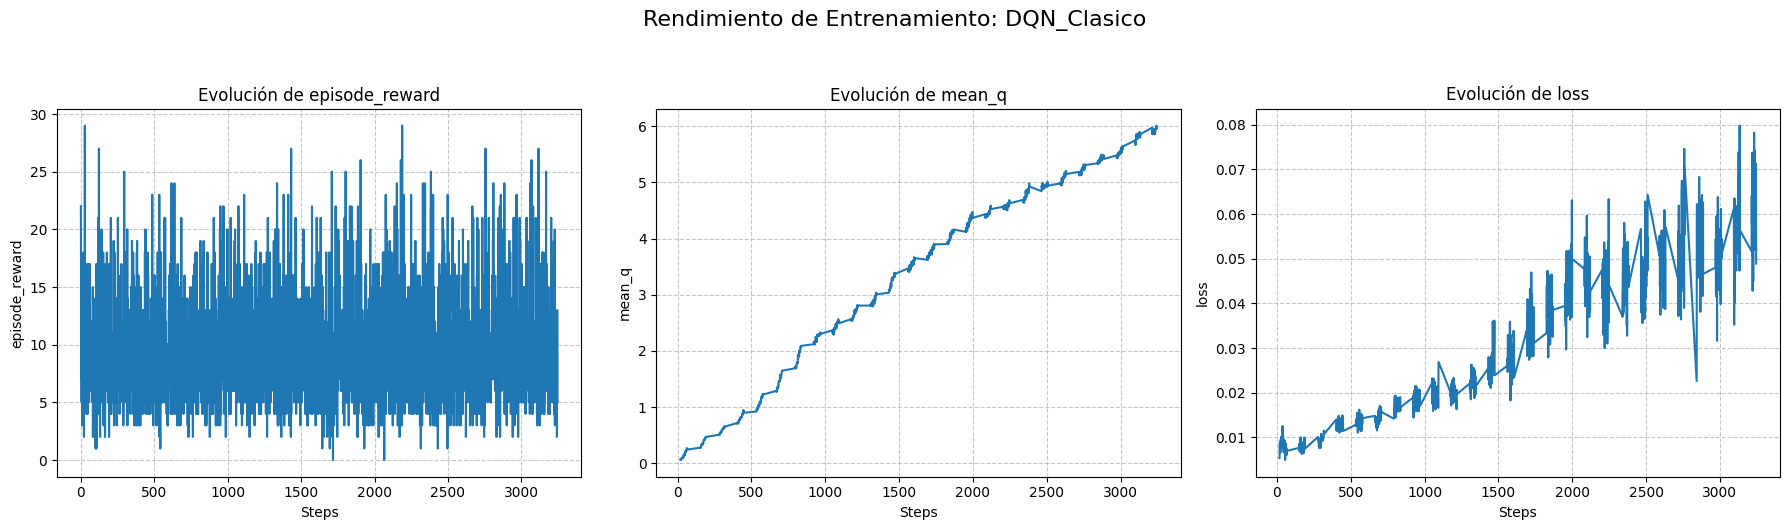

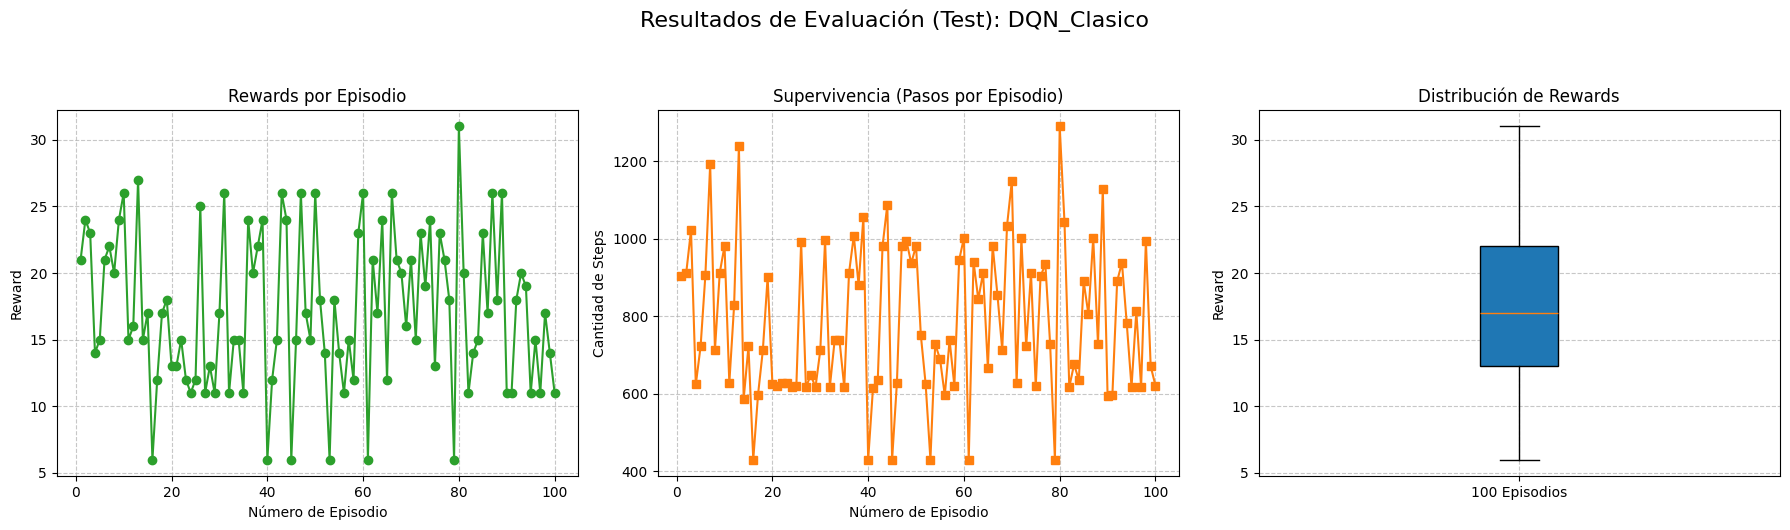


Resultados del Agente: DQN Clásico
Rendimiento promedio: 17.24
Rendimiento mínimo: 6.0
Rendimiento máximo: 31.0
Desviación estándar: 5.729083696368906


In [ ]:
graph_training(DQN_CLASICO_LOGS,model_name= "DQN_Clasico", variables=["episode_reward", "mean_q", "loss"])
graph_test_results(clasico_results.history, model_name= "DQN_Clasico")
print("")
print_results("DQN Clásico", clasico_results)

###### **Conclusiones**



##### **DQN Spatial**

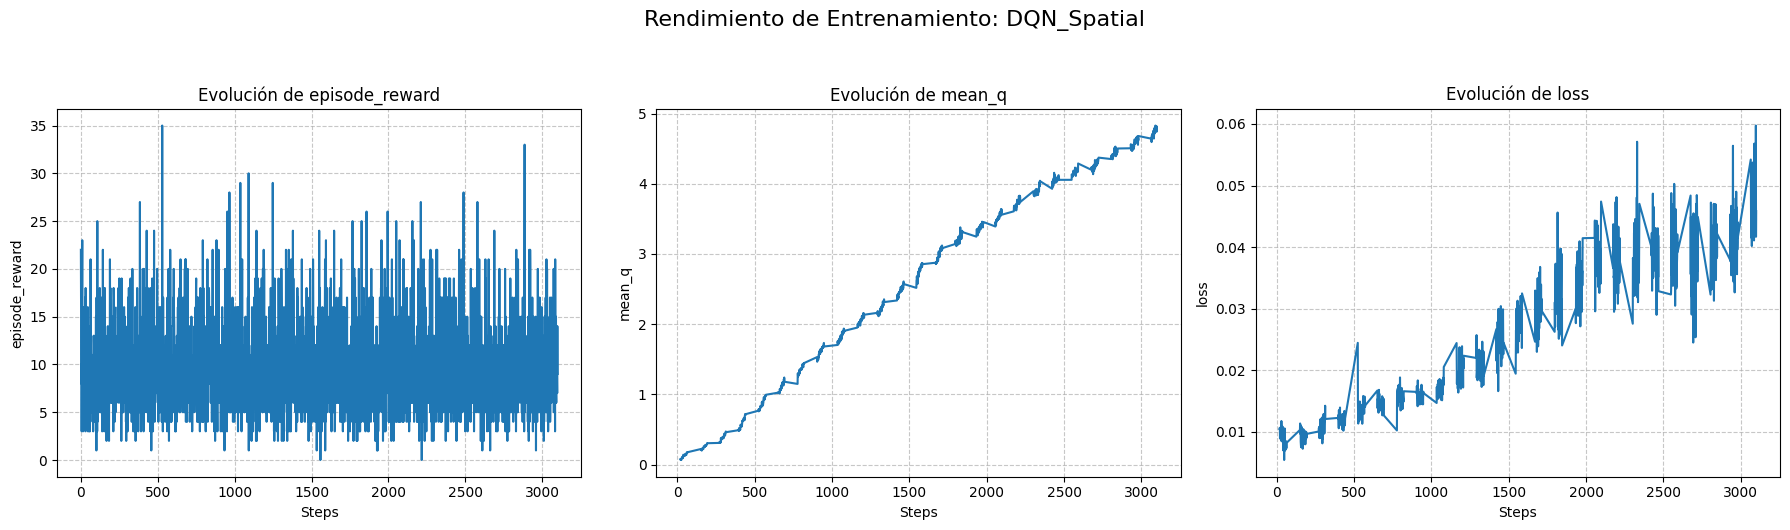

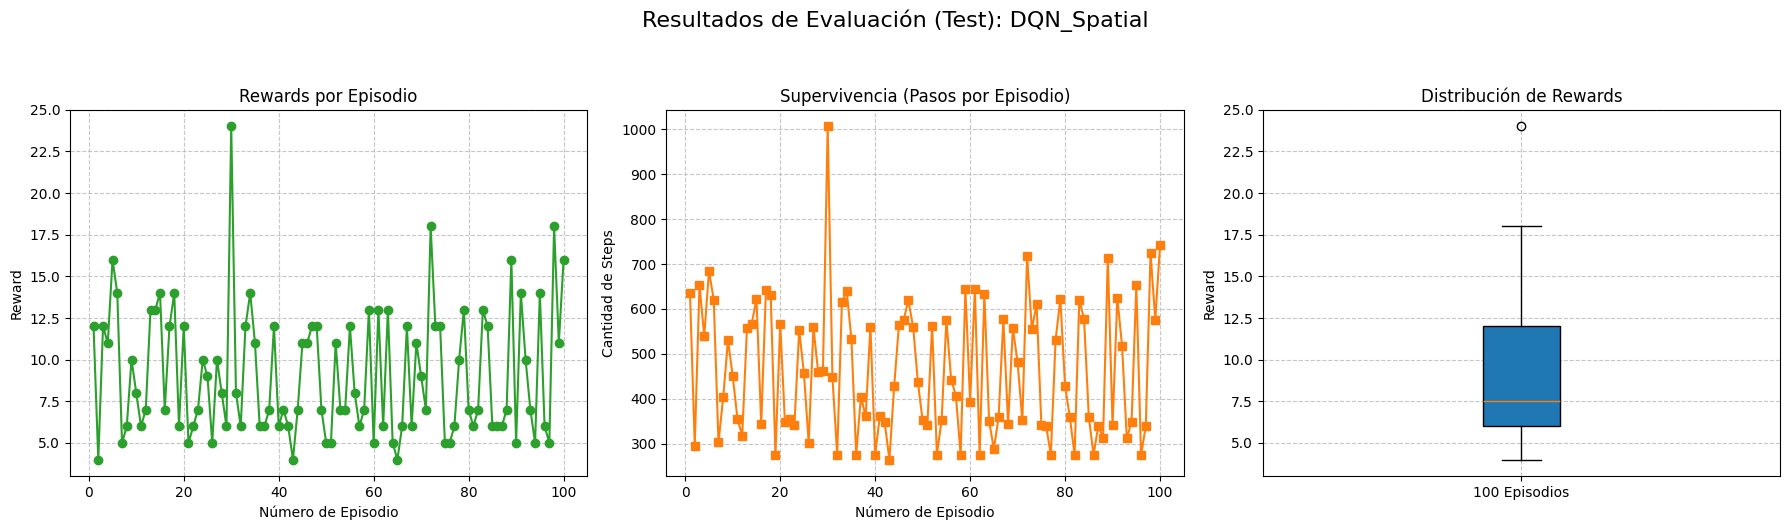


Resultados del Agente: DQN Spatial
Rendimiento promedio: 9.13
Rendimiento mínimo: 4.0
Rendimiento máximo: 24.0
Desviación estándar: 3.8148525528518133


In [ ]:
graph_training(DQN_SPATIAL_LOGS,model_name= "DQN_Spatial", variables=["episode_reward", "mean_q", "loss"])
graph_test_results(spatial_results.history, model_name= "DQN_Spatial")
print("")
print_results("DQN Spatial", spatial_results)

###### **Conclusiones**



##### **DQN Dueling**

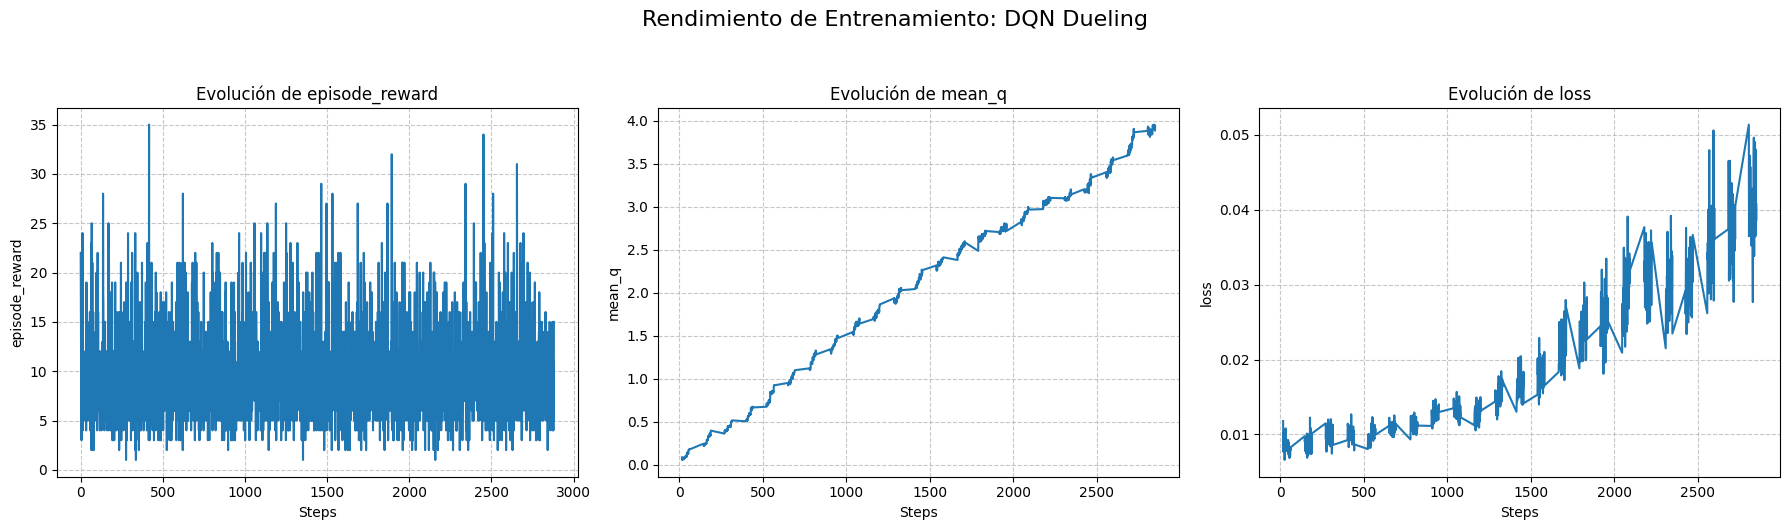

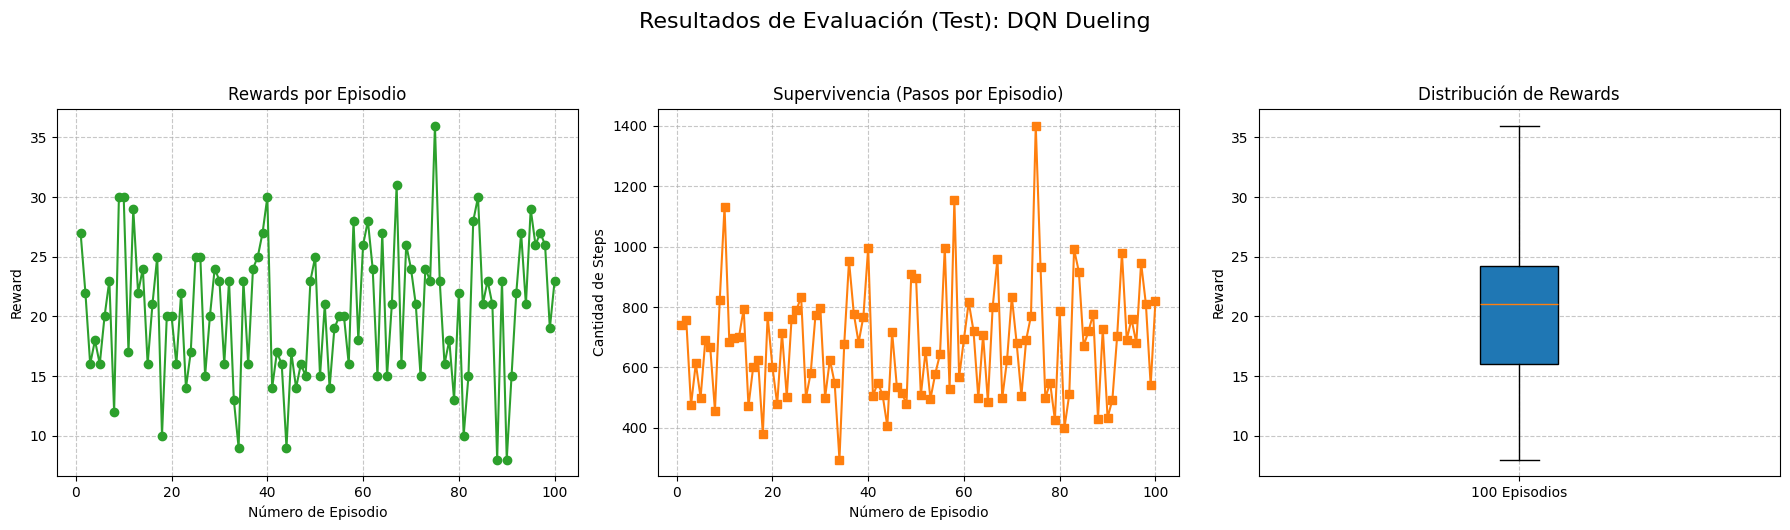


Resultados del Agente: DQN Dueling
Rendimiento promedio: 20.48
Rendimiento mínimo: 8.0
Rendimiento máximo: 36.0
Desviación estándar: 5.74191605650936


In [ ]:
graph_training(DQN_DUELING_LOGS, model_name= "DQN Dueling", variables=["episode_reward", "mean_q", "loss"])
graph_test_results(dueling_results.history, model_name= "DQN Dueling")
print("")
print_results("DQN Dueling", dueling_results)

###### **Conclusiones**



---

### **Conclusiones Generales**

